In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

svm = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/compare/robustness_results_svm.csv"
)

cnn = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/compare/robustness_results_cnn.csv"
)

graph = pd.read_csv(
    "/content/drive/MyDrive/FP_AI_2026/compare/robustness_result_graphcodebert.csv"
)

svm["Model"] = "SVM"
cnn["Model"] = "CNN"
graph["Model"] = "GraphCodeBERT"

robustness_compare = pd.concat(
    [svm, cnn, graph],
    ignore_index=True
)

robustness_compare

,Scenario,Accuracy,Precision,Recall,F1,AUC,Model
0,Original,0.92,0.920000,0.92,0.920000,0.9688,SVM
1,Variable Renaming,0.92,0.920000,0.92,0.920000,0.9700,SVM
2,Comment Injection,0.92,0.920000,0.92,0.920000,0.9692,SVM
3,Original,0.96,0.942308,0.98,0.960784,0.9952,CNN
4,Variable Renaming,0.96,0.925926,1.00,0.961538,0.9944,CNN
5,Comment Injection,0.96,0.942308,0.98,0.960784,0.9952,CNN
6,Original,0.99,0.980392,1.00,0.990099,0.9964,GraphCodeBERT
7,Variable Renaming,0.98,0.961538,1.00,0.980392,0.9960,GraphCodeBERT
8,Comment Injection,0.98,0.961538,1.00,0.980392,0.9956,GraphCodeBERT


In [ ]:
summary = robustness_compare[
    [
        "Model",
        "Scenario",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
]

summary

,Model,Scenario,Accuracy,Precision,Recall,F1,AUC
0,SVM,Original,0.92,0.920000,0.92,0.920000,0.9688
1,SVM,Variable Renaming,0.92,0.920000,0.92,0.920000,0.9700
2,SVM,Comment Injection,0.92,0.920000,0.92,0.920000,0.9692
3,CNN,Original,0.96,0.942308,0.98,0.960784,0.9952
4,CNN,Variable Renaming,0.96,0.925926,1.00,0.961538,0.9944
5,CNN,Comment Injection,0.96,0.942308,0.98,0.960784,0.9952
6,GraphCodeBERT,Original,0.99,0.980392,1.00,0.990099,0.9964
7,GraphCodeBERT,Variable Renaming,0.98,0.961538,1.00,0.980392,0.9960
8,GraphCodeBERT,Comment Injection,0.98,0.961538,1.00,0.980392,0.9956


In [ ]:
summary.to_csv(
    "/content/drive/MyDrive/FP_AI_2026/compare/robustness_comparison.csv",
    index=False
)

print("Saved!")

Saved!


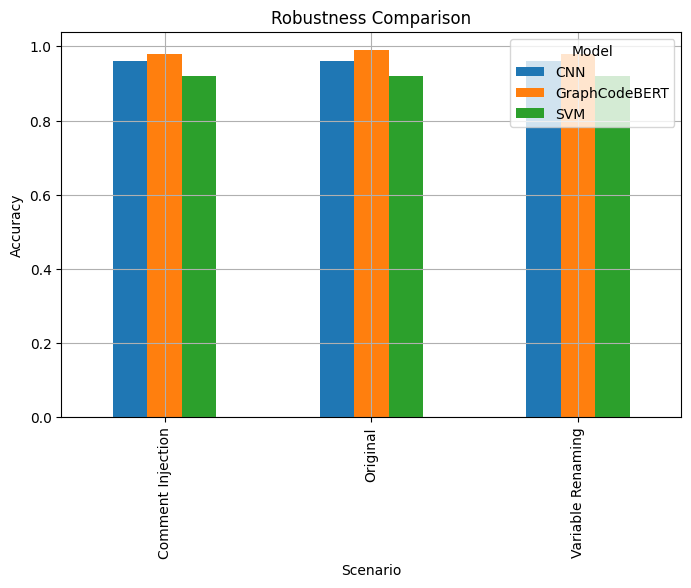

In [ ]:
import matplotlib.pyplot as plt

pivot_acc = summary.pivot(
    index="Scenario",
    columns="Model",
    values="Accuracy"
)

pivot_acc.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Accuracy")
plt.title("Robustness Comparison")
plt.grid(True)
plt.show()

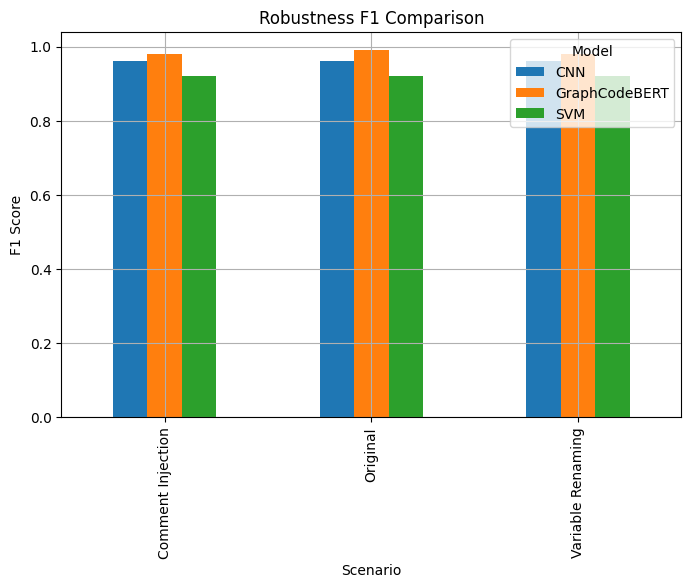

In [ ]:
pivot_f1 = summary.pivot(
    index="Scenario",
    columns="Model",
    values="F1"
)

pivot_f1.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("F1 Score")
plt.title("Robustness F1 Comparison")
plt.grid(True)
plt.show()